In [1]:
import os
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('notebook')

In [2]:
CONV_DIR = '../examples/comparisons/closed_boundary_DIIID/convergence_w25'
BF_DIR = '../examples/comparisons/closed_boundary_DIIID/brute_force'

rows = []
for config in sorted(os.listdir(CONV_DIR)):
    m = re.match(r'lambda:([^,]+),coils:(\d+)', config)
    if not m:
        continue
    lam, coils = float(m.group(1)), int(m.group(2))
    config_dir = os.path.join(CONV_DIR, config)

    bf_path = os.path.join(BF_DIR, f'lambda:{lam},coils:{coils}', 'results.json')
    bf_cost = float('nan')
    if os.path.exists(bf_path):
        with open(bf_path) as f:
            bf_cost = json.load(f)['best_cost']

    for run_dir in sorted(os.listdir(config_dir)):
        rpath = os.path.join(config_dir, run_dir, 'results.json')
        if not os.path.isfile(rpath):
            continue
        run_m = re.match(r'run_(\d+)', run_dir)
        run_idx = int(run_m.group(1)) if run_m else 0

        with open(rpath) as f:
            data = json.load(f)

        lbfgs = data['methods'].get('Multi-start L-BFGS', {})
        bayes = data['methods'].get('Bayesian', {})
        if not bayes:
            continue

        ref_costs = bayes.get('refinement_costs', [])
        ref_evals = bayes.get('refinement_evals', [])
        ref_times = bayes.get('refinement_times', [])
        n_bo = int(bayes.get('n_bayesian_evals', 0))
        n_initial = int(bayes.get('n_initial', 0))
        pts = int(bayes.get('pts_refined', 0))
        lbfgs_ev = int(lbfgs.get('n_evals', 0))
        lbfgs_st = int(lbfgs.get('starts_completed', 0))

        rows.append({
            'config': config,
            'lambda': lam,
            'coils': coils,
            'run': run_idx,
            'random_state': bayes.get('random_state'),
            # costs
            'bayes_cost': bayes.get('best_cost', float('nan')),
            'lbfgs_cost': lbfgs.get('best_cost', float('nan')),
            'bf_cost': bf_cost,
            # eval counts
            'bayes_total_evals': int(bayes.get('n_evals', 0)),
            'n_bayesian_evals': n_bo,
            'n_initial': n_initial,
            'n_gp_guided': n_bo - n_initial,
            'n_gp_obs': int(bayes.get('n_gp_observations', n_bo)),
            'lbfgs_evals': lbfgs_ev,
            'lbfgs_starts': lbfgs_st,
            'lbfgs_evals_per_pt': lbfgs_ev / lbfgs_st if lbfgs_st > 0 else float('nan'),
            # phase 2 refinement
            'acq_multiplier': bayes.get('acq_multiplier'),
            'n_acq_candidates': bayes.get('n_acq_candidates'),
            'acq_dedup_tol': bayes.get('acq_dedup_tol'),
            'unique_target': bayes.get('unique_refined_points'),
            'n_acq_unique': bayes.get('n_acq_unique'),
            'pts_refined': pts,
            'ref_costs_list': ref_costs,
            'ref_evals_list': ref_evals,
            'ref_times_list': ref_times,
            'ref_evals_total': sum(ref_evals) if ref_evals else 0,
            'ref_evals_mean': float(np.mean(ref_evals)) if ref_evals else float('nan'),
            # timing
            'bayes_time': float(bayes.get('time', 0)),
            'bayes_phase1_time': float(bayes.get('time_bayesian_phase', 0)),
            'lbfgs_time': float(lbfgs.get('time', 0)),
            'total_ref_time': sum(ref_times) if ref_times else float('nan'),
            # stopping
            'bayes_stopping': bayes.get('bayesian_stopping'),
            'ref_stopping': bayes.get('refinement_stopping'),
        })

df = pd.DataFrame(rows)
print(f'Loaded {len(df)} runs across {df["config"].nunique()} configs')
df.head()

Loaded 180 runs across 9 configs


,config,lambda,coils,run,random_state,bayes_cost,lbfgs_cost,bf_cost,bayes_total_evals,n_bayesian_evals,...,ref_evals_list,ref_times_list,ref_evals_total,ref_evals_mean,bayes_time,bayes_phase1_time,lbfgs_time,total_ref_time,bayes_stopping,ref_stopping
0,"lambda:1e-05,coils:2",0.00001,2,1,2,0.032574,0.032574,0.033003,837,132,...,"[200, 115, 105, 105, 180]","[0.5958125591278076, 0.20454716682434082, 0.19...",705,141.0,244.015587,97.602289,6.878936,1.506958,bayesian_stagnation,all refinements completed
1,"lambda:1e-05,coils:2",0.00001,2,2,3,0.032574,0.032574,0.033003,975,125,...,"[110, 170, 160, 200, 210]","[0.29999423027038574, 0.3696415424346924, 0.28...",850,170.0,235.166422,87.388173,6.323568,1.699480,bayesian_stagnation,all refinements completed
2,"lambda:1e-05,coils:2",0.00001,2,3,4,0.032574,0.032574,0.033003,572,127,...,"[75, 90, 75, 100, 105]","[0.22672104835510254, 0.23293375968933105, 0.1...",445,89.0,248.989643,93.941564,7.895107,1.042871,bayesian_stagnation,all refinements completed
3,"lambda:1e-05,coils:2",0.00001,2,4,5,0.032574,0.032574,0.033003,665,120,...,"[115, 120, 110, 90, 110]","[0.31763434410095215, 0.26984095573425293, 0.1...",545,109.0,180.906725,64.661674,7.260349,1.154453,bayesian_stagnation,all refinements completed
4,"lambda:1e-05,coils:2",0.00001,2,5,6,0.032574,0.032574,0.033003,698,123,...,"[110, 170, 180, 85, 30]","[0.29822635650634766, 0.36349916458129883, 0.3...",575,115.0,219.049093,81.129230,6.789239,1.191525,bayesian_stagnation,all refinements completed


In [3]:
K = 3 # number of refinement points to use

def _kr(row):
    costs = row['ref_costs_list']
    evals = row['ref_evals_list']
    times = row['ref_times_list']
    if len(costs) >= K and len(evals) >= K:
        return pd.Series({
            'bayes_Kr_cost':  float(costs[K-1]),
            'bayes_Kr_evals': row['n_bayesian_evals'] + int(sum(evals[:K])),
            'bayes_Kr_time':  row['bayes_phase1_time'] + (float(sum(times[:K])) if len(times) >= K else float('nan')),
        })
    return pd.Series({'bayes_Kr_cost': float('nan'), 'bayes_Kr_evals': float('nan'), 'bayes_Kr_time': float('nan')})

kr = df.apply(_kr, axis=1)
df['bayes_Kr_cost']  = kr['bayes_Kr_cost']
df['bayes_Kr_evals'] = kr['bayes_Kr_evals']
df['bayes_Kr_time']  = kr['bayes_Kr_time']
print(f"{df['bayes_Kr_cost'].notna().sum()} / {len(df)} runs have >= {K} refinements")

180 / 180 runs have >= 3 refinements


In [4]:
# Refinement & function call breakdown — averaged over runs per config
summary = df.groupby(['lambda', 'coils']).agg(
    n_runs=('run', 'count'),
    ph1_init=('n_initial', 'mean'),
    ph1_gp=('n_gp_guided', 'mean'),
    acq_cands=('n_acq_candidates', 'mean'),
    unique_refined=('pts_refined', 'mean'),
    ph2_evals_per_pt=('ref_evals_mean', 'mean'),
    bayes_total=('bayes_total_evals', 'mean'),
    lbfgs_total=('lbfgs_evals', 'mean'),
    lbfgs_evals_per_pt=('lbfgs_evals_per_pt', 'mean'),
    lbfgs_starts=('lbfgs_starts', 'mean'),
).reset_index()

summary['lambda'] = summary['lambda'].apply(lambda x: f'1e-{int(-np.log10(x))}')

pd.set_option('display.float_format', '{:.1f}'.format)
display(summary)

,lambda,coils,n_runs,ph1_init,ph1_gp,acq_cands,unique_refined,ph2_evals_per_pt,bayes_total,lbfgs_total,lbfgs_evals_per_pt,lbfgs_starts
0,1e-8,2,20,71.0,43.3,50.0,5.0,192.1,1074.5,5815.8,213.7,27.2
1,1e-8,3,20,130.0,28.6,50.0,5.0,478.5,2551.2,14119.4,506.9,27.9
2,1e-8,4,20,200.0,27.7,50.0,5.0,751.4,3984.8,34493.8,814.3,42.4
3,1e-7,2,20,71.0,48.3,50.0,5.0,198.3,1110.8,5742.5,210.7,27.2
4,1e-7,3,20,130.0,27.9,50.0,5.0,402.1,2168.2,11446.0,430.3,26.6
5,1e-6,2,20,71.0,49.6,50.0,5.0,146.3,852.1,4201.8,156.8,26.8
6,1e-6,3,20,130.0,33.0,50.0,5.0,332.9,1827.2,9548.0,350.2,27.2
7,1e-5,2,20,71.0,48.2,50.0,5.0,119.7,717.8,3686.2,126.3,29.2
8,1e-5,3,20,130.0,53.5,50.0,5.0,237.4,1370.4,10864.4,306.6,35.4


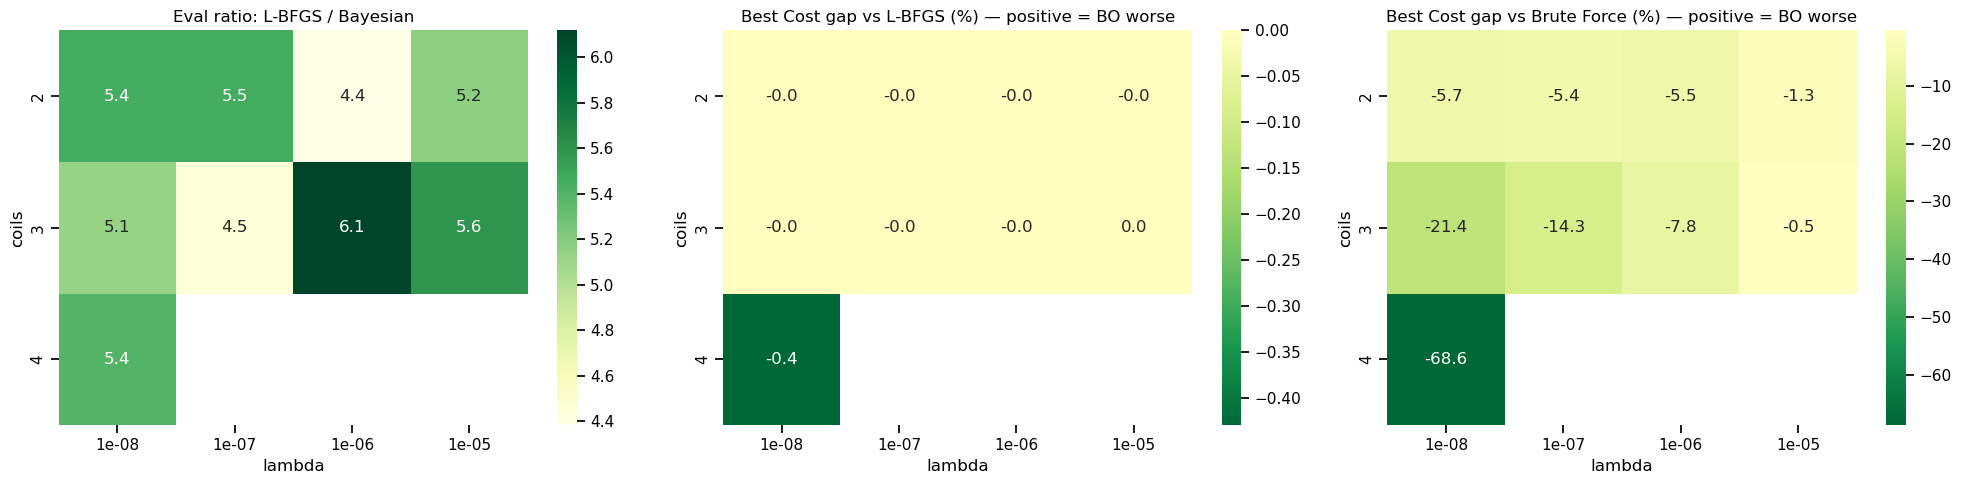

In [5]:
# Best cost per config (best run if multiple)
best = df.sort_values('bayes_cost').groupby('config', sort=False).first().reset_index()
best['cost_gap_lbfgs'] = (best['bayes_cost'] - best['lbfgs_cost']) / best['lbfgs_cost'] * 100
best['cost_gap_bf']    = (best['bayes_cost'] - best['bf_cost'])    / best['bf_cost']    * 100
best['eval_ratio']     = best['lbfgs_evals'] / best['bayes_total_evals']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, col, title, fmt in [
    (axes[0], 'eval_ratio',     'Eval ratio: L-BFGS / Bayesian',                   '.1f'),
    (axes[1], 'cost_gap_lbfgs', 'Best Cost gap vs L-BFGS (%) — positive = BO worse',    '.1f'),
    (axes[2], 'cost_gap_bf',    'Best Cost gap vs Brute Force (%) — positive = BO worse','.1f'),
]:
    pivot = best.pivot_table(index='coils', columns='lambda', values=col)
    pivot = pivot.reindex(sorted(pivot.columns), axis=1)
    cmap  = 'YlGn' if col == 'eval_ratio' else 'RdYlGn_r'
    center = None if col == 'eval_ratio' else 0
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, ax=ax, center=center)
    ax.set_title(title)
    ax.set_xlabel('lambda')
    ax.set_ylabel('coils')

plt.tight_layout()
plt.show()

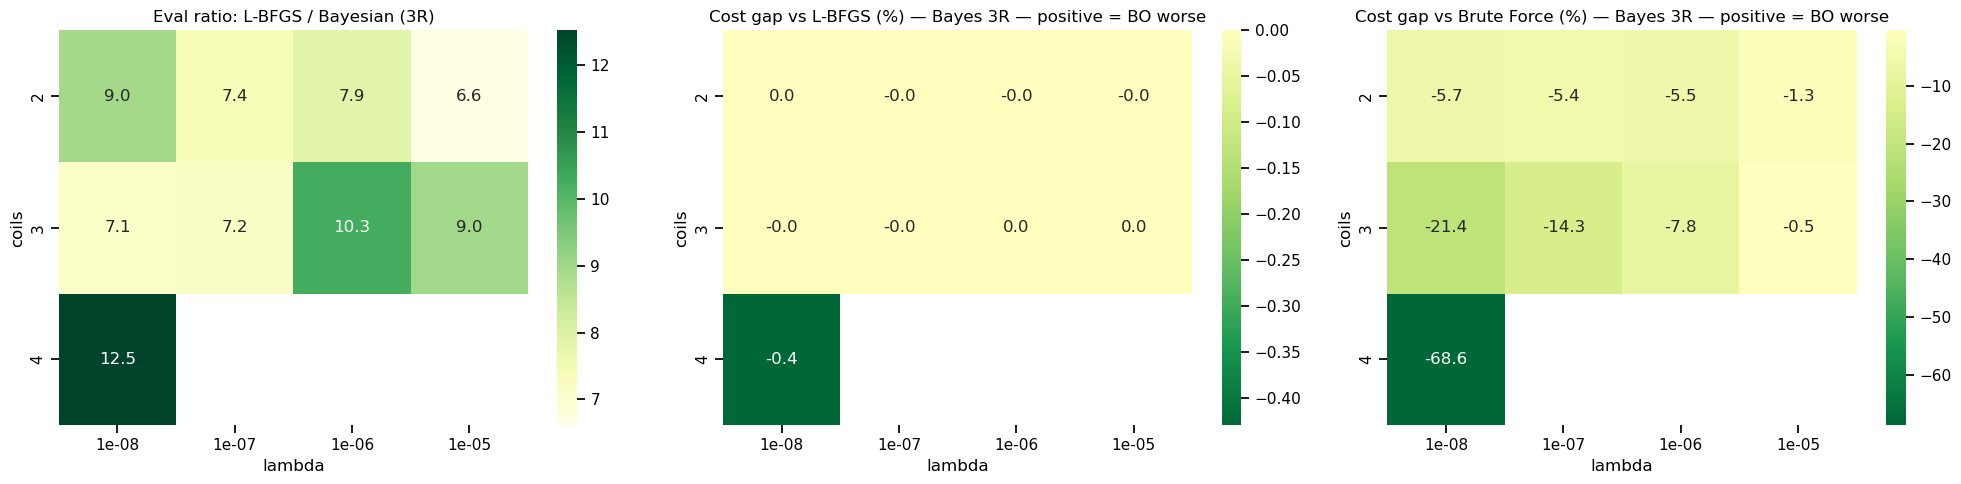

In [6]:
# Best cost per config capped at K refinement points
valid = df.dropna(subset=['bayes_Kr_cost'])
best_kr = valid.sort_values('bayes_Kr_cost').groupby('config', sort=False).first().reset_index()
best_kr['cost_gap_lbfgs'] = (best_kr['bayes_Kr_cost'] - best_kr['lbfgs_cost']) / best_kr['lbfgs_cost'] * 100
best_kr['cost_gap_bf']    = (best_kr['bayes_Kr_cost'] - best_kr['bf_cost'])    / best_kr['bf_cost']    * 100
best_kr['eval_ratio']     = best_kr['lbfgs_evals'] / best_kr['bayes_Kr_evals']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, col, title, fmt in [
    (axes[0], 'eval_ratio',     f'Eval ratio: L-BFGS / Bayesian ({K}R)',                           '.1f'),
    (axes[1], 'cost_gap_lbfgs', f'Cost gap vs L-BFGS (%) — Bayes {K}R — positive = BO worse',     '.1f'),
    (axes[2], 'cost_gap_bf',    f'Cost gap vs Brute Force (%) — Bayes {K}R — positive = BO worse', '.1f'),
]:
    pivot = best_kr.pivot_table(index='coils', columns='lambda', values=col)
    pivot = pivot.reindex(sorted(pivot.columns), axis=1)
    cmap  = 'YlGn' if col == 'eval_ratio' else 'RdYlGn_r'
    center = None if col == 'eval_ratio' else 0
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, ax=ax, center=center)
    ax.set_title(title)
    ax.set_xlabel('lambda')
    ax.set_ylabel('coils')

plt.tight_layout()
plt.show()

In [7]:
# Runs analyzed per (coils, lambda)
counts = df.groupby(['coils', 'lambda']).size().reset_index(name='n_runs')
pivot = counts.pivot(index='coils', columns='lambda', values='n_runs').fillna(0).astype(int)
pivot.columns = [f'{c:.0e}' for c in pivot.columns]
display(pivot)

,1e-08,1e-07,1e-06,1e-05
coils,,,,
2,20,20,20,20
3,20,20,20,20
4,20,0,0,0


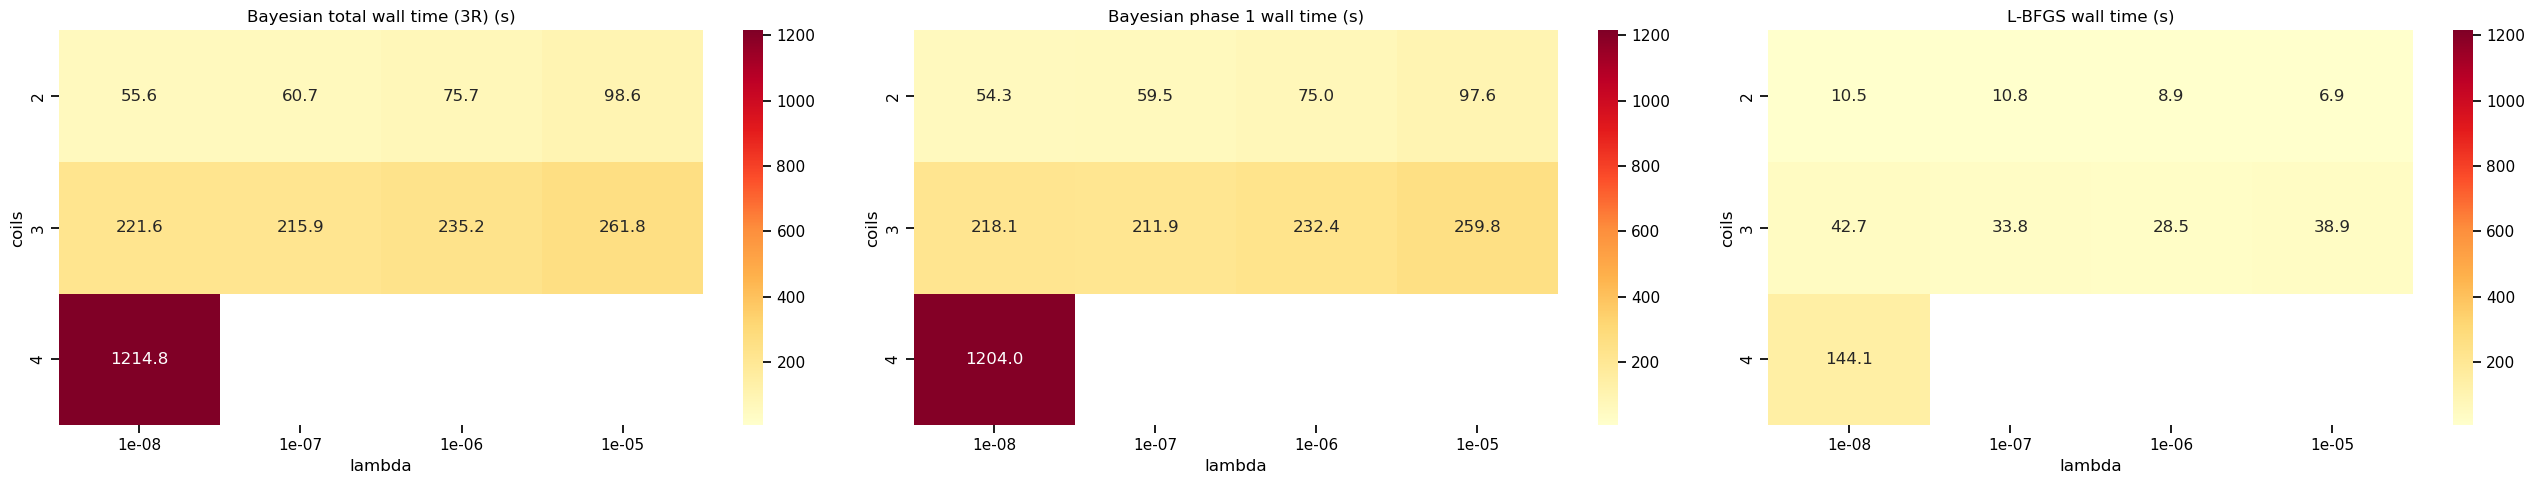

In [8]:
# Wall-clock time breakdown (Bayesian capped at K refinements)
valid = df.dropna(subset=['bayes_Kr_time'])
timing = valid.groupby(['coils', 'lambda']).first().reset_index()

lams = sorted(timing['lambda'].unique())
pivots = {
    col: timing.pivot_table(index='coils', columns='lambda', values=col).reindex(lams, axis=1)
    for col in ['bayes_Kr_time', 'bayes_phase1_time', 'lbfgs_time']
}

vmin = min(p.min().min() for p in pivots.values())
vmax = max(p.max().max() for p in pivots.values())

titles = {
    'bayes_Kr_time':    f'Bayesian total wall time ({K}R) (s)',
    'bayes_phase1_time': 'Bayesian phase 1 wall time (s)',
    'lbfgs_time':        'L-BFGS wall time (s)',
}

fig, axes = plt.subplots(1, 3, figsize=(26, 5))
for ax, (col, pivot) in zip(axes, pivots.items()):
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, vmin=vmin, vmax=vmax)
    ax.set_title(titles[col])
    ax.set_xlabel('lambda')
    ax.set_ylabel('coils')

plt.tight_layout()
plt.show()

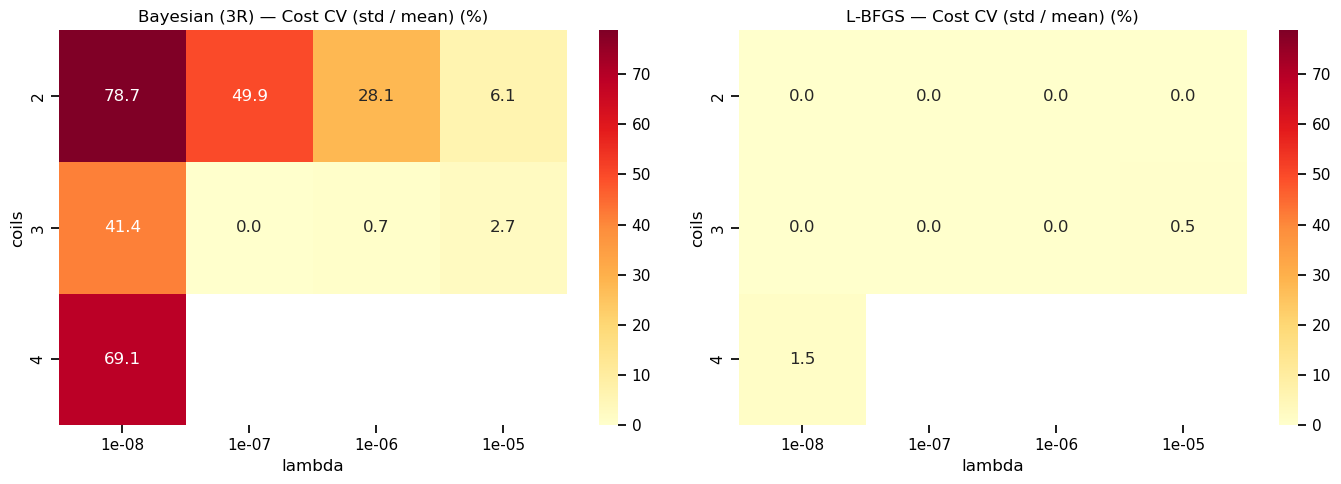

,coils,lambda,n,bayes_mean,bayes_std,bayes_cv,lbfgs_mean,lbfgs_std,lbfgs_cv
0,2,0.0,20,0.0,0.0,78.7,0.0,0.0,0.0
1,2,0.0,20,0.0,0.0,49.9,0.0,0.0,0.0
2,2,0.0,20,0.0,0.0,28.1,0.0,0.0,0.0
3,2,0.0,20,0.0,0.0,6.1,0.0,0.0,0.0
4,3,0.0,20,0.0,0.0,41.4,0.0,0.0,0.0
5,3,0.0,20,0.0,0.0,0.0,0.0,0.0,0.0
6,3,0.0,20,0.0,0.0,0.7,0.0,0.0,0.0
7,3,0.0,20,0.0,0.0,2.7,0.0,0.0,0.5
8,4,0.0,20,0.0,0.0,69.1,0.0,0.0,1.5


In [9]:
# Cost CV across runs (std / mean * 100%) — capped at K refinements
valid = df.dropna(subset=['bayes_Kr_cost'])
multi = valid.groupby(['coils', 'lambda']).filter(lambda g: len(g) > 1)

if len(multi) == 0:
    print('Only single runs found — re-run with N_RUNS > 1 to see variance.')
else:
    stats = multi.groupby(['coils', 'lambda']).agg(
        bayes_mean=('bayes_Kr_cost', 'mean'), bayes_std=('bayes_Kr_cost', 'std'),
        lbfgs_mean=('lbfgs_cost',    'mean'), lbfgs_std=('lbfgs_cost',    'std'),
        n=('bayes_Kr_cost', 'count'),
    ).reset_index()
    stats['bayes_cv'] = stats['bayes_std'] / stats['bayes_mean'] * 100
    stats['lbfgs_cv'] = stats['lbfgs_std'] / stats['lbfgs_mean'] * 100

    vmin = min(stats['bayes_cv'].min(), stats['lbfgs_cv'].min())
    vmax = max(stats['bayes_cv'].max(), stats['lbfgs_cv'].max())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, col, title in [
        (axes[0], 'bayes_cv', f'Bayesian ({K}R) — Cost CV (std / mean) (%)'),
        (axes[1], 'lbfgs_cv', 'L-BFGS — Cost CV (std / mean) (%)'),
    ]:
        pivot = stats.pivot_table(index='coils', columns='lambda', values=col)
        pivot = pivot.reindex(sorted(pivot.columns), axis=1)
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_xlabel('lambda')
        ax.set_ylabel('coils')

    plt.tight_layout()
    plt.show()
    display(stats[['coils', 'lambda', 'n', 'bayes_mean', 'bayes_std', 'bayes_cv', 'lbfgs_mean', 'lbfgs_std', 'lbfgs_cv']])